# Exercise 2 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Pakawat Nutthanithipat

Sciper number: 423110

#### Group Member 2:
Name: Balázs Peisz

Sciper number: 390226

#### Group Member 3:
Name: Andreas Wendelboe

Sciper number: 423025

#### Group Member 4:
Name:

Sciper number:

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

# Linear Programming exercise

In [ ]:
### Do the imports -- no need to change this
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

In [ ]:
reward_mode = 2 # see below to visualize the reward function
size = 3 # size of the gridworld (3x3)
prop = 0.1 # proportion of randomly taken steps due to noise in the environment 
gamma=0.99 # discount factor

gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
print('Reward function: \n', gridworld.r) # visualize the reward function

Reward function: 
 [[   0.    0.    0.    0.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [-100. -100. -100. -100.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]]


We will use a solver to compute the **optimal value function** to measure the suboptimality of the policies produced by our algorithms.

To access the optimal value function use `solver.v`.

In [ ]:
solver = MDPsolver(gridworld) # call the MDPsolver class
solver.value_iteration() # call the value iteration method to find V^* once

## Ex 1: Solving the Primal [20 points]

We will leverage the powerful `scipy` library to solve **Linear Programs (LPs)**. Below we give an example of using the [linprog module](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linprog.html) to solve a simple LP:

\begin{aligned}
 & \min_{x := \begin{bmatrix}
x_0  \\
x_1
\end{bmatrix}  \in \mathbb{R}^2}  \begin{bmatrix}
-1  \\
4
\end{bmatrix} ^\top x
\\&  \text{s.t.}  \begin{bmatrix}
-3 & 1 \\
1 & 2 
\end{bmatrix} \mathbb{x} \le  \begin{bmatrix}
6  \\
4 
\end{bmatrix} , \quad  x_1\ge -3 \,.
\end{aligned}

The **code example below will be instructive** when you later construct the LP corresponding to the MDP.

In [ ]:
from scipy.optimize import linprog # import the linear programming solver from scipy

# Note that the bounds argument in linprog is a  sequence of (min, max) pairs for each element in x, defining the minimum and maximum values.
x0_bounds = (None, None)
x1_bounds = (-3, None)

# call linear programming solver:
res = linprog([-1, 4], 
              A_ub=[[-3, 1], [1, 2]], 
              b_ub=[6, 4], 
              bounds=[x0_bounds, x1_bounds],
              method="simplex")
print('The solution is ', res.x) # access and print the solution
print(res.message) # print the message of the solver (e.g., terminated successfully)

The solution is  [10. -3.]
Optimization terminated successfully.


/var/folders/7y/2z6fy9wj2gvdg90fmrn33q4h0000gn/T/ipykernel_15317/2674117054.py:8: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  res = linprog([-1, 4],


Now we are ready to use `linprog` to solve the LP problem in gridworld.

We define a distribution `mu` over the states.

In [ ]:
mu = np.ones((gridworld.n_states,1))/gridworld.n_states # initialize mu

Next, we need to **instantiate the constraints of the primal problem**. Notice that `scipy` requires the inequality constraints in the form $A_{ub} x \leq b_{ub}$.


To this end, we rewrite the constraint $EV \geq \gamma P V + r$ in the form expected by `scipy`.

In [ ]:
def build_matrix(env):
    E = np.kron(np.eye(env.n_states), np.ones(env.n_actions)).T # build the matrix E
    P = env.T.transpose((1,0,2)).reshape(env.n_states*env.n_actions, -1) # build the matrix P
    return env.gamma*P - E

(Side remark: The indexing in the matrices `E` and `P` here is slightly different from the one in the lecture. This does not change any of the formulas from the slides since both matrices are indexed in the same way, consistently throughout this exercise. You may ignore this comment.)

Then, use the function `linprog` of `scipy` to solve the dual problem and show that you can retrieve the same $V^\star$ computed with the solver and stored in `solver.v`

In [ ]:
# Call linear programming solver with the correct inputs:
primal_out = linprog((1-gridworld.gamma)*mu.flatten(), 
                     A_ub=build_matrix(gridworld), 
                     b_ub=-gridworld.r.flatten(),
                     method="simplex",
                     bounds=(None, None))

/var/folders/7y/2z6fy9wj2gvdg90fmrn33q4h0000gn/T/ipykernel_15317/1962059975.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  primal_out = linprog((1-gridworld.gamma)*mu.flatten(),


(*Hint:* Check slide 23 for the matrix form (or slide 8), lecture 3 to recall the primal.)

We can access the solution of the primal LP using `primal_out.x`. Compare the error with the value of `solver.v`.

In [ ]:
np.linalg.norm(primal_out.x - solver.v) # plot 2-norm

np.float64(4.111484296790486e-14)

***Question***

By running the following two cells, plot (in matrix form) `mu` and the difference between `solver.v` and `primal_out.x`. Then, answer the following question: Can we ensure that `np.linalg.norm(primal_out.x - solver.v)` is zero (up to numerical errors) for the current value of `mu`?  

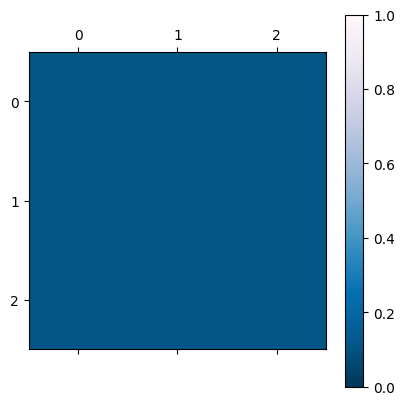

In [ ]:
plt.matshow(mu.reshape(size, size), cmap='PuBu_r', vmin=0,vmax=1) # plot distribution mu over states 
plt.colorbar()

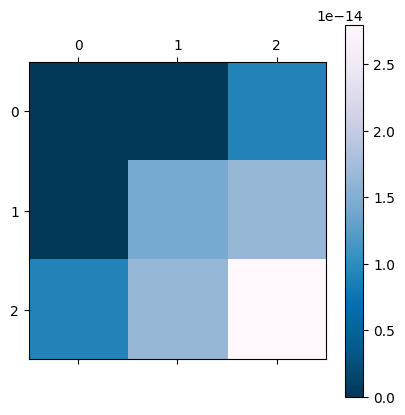

In [ ]:
plt.matshow((solver.v - primal_out.x).reshape(size, size), cmap='PuBu_r') # plot the difference between the value function and the solution of the linear program
plt.colorbar()

**Answer**

For the current value of mu (1/9 everywhere), the LP cares about each state's values equally and makes them all coincide with V*. The current 2-norm is due floating point errors not related to the exercise.

Next, we repeat the same experiment with a different value of `mu`. 

Note that we do **not** overwrite `mu` or `primal_out` (but instead have `mu2` and `primal_out2`, since for all other exercises, we will use the original, uniform `mu`.)

In [ ]:
# overwrite mu with a new distribution:
mu2 = np.zeros((gridworld.n_states,1))
mu2[-3] = 1

In [ ]:
mu2

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.]])

Fill in the following, as before but for the distribution `mu2`.

In [ ]:
# solve the LP with the new mu2:
primal_out2 = linprog((1-gridworld.gamma)*mu2.flatten(), 
                    A_ub=build_matrix(gridworld), 
                    b_ub=-gridworld.r.flatten(),
                    method="simplex",
                    bounds=(None, None))

/var/folders/7y/2z6fy9wj2gvdg90fmrn33q4h0000gn/T/ipykernel_15317/924758714.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  primal_out2 = linprog((1-gridworld.gamma)*mu2.flatten(),


We compare with the value computed by Value Iteration `solver.v`.

In [ ]:
np.linalg.norm(primal_out2.x - solver.v) # plot 2-norm

np.float64(2.772246430099758)

Note that now, the optimal solution of the primal LP `primal_out2.x` and the optimal value function `solver.v` do not coincide anymore! 

This is despite the fact that the optimal value function `solver.v` was computed **right in the beginning**, before we even initialized the `mu` for solving the LP the first time. So `solver.v` is definitely the correct optimal value function for each state.

**Question:**

Why does it make sense that the two values do not coincide?

**Answer:**

The mu is no longer uniform, instead everything is 0 except one state. That means it is the only state that the LP cares about. It does not care about solving the other states (although it might still do it, if it is related to solving for the one state). The difference between LP and solver is therefore much higher than before.

***Question***

We plot again in matrix form `mu2`, `solver.v` and `primal_out2.x`. Then answer the following: What can happen in the states where `mu2 = 0`?

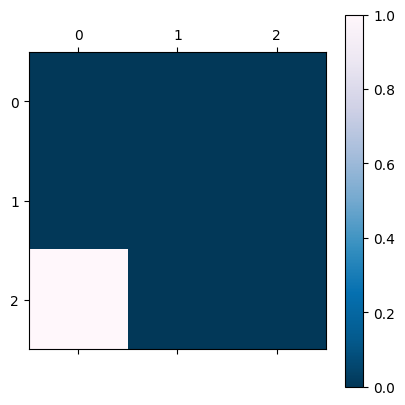

In [ ]:
plt.matshow(mu2.reshape(size, size), cmap='PuBu_r', vmin=0,vmax=1) # plot distribution mu over states
plt.colorbar()

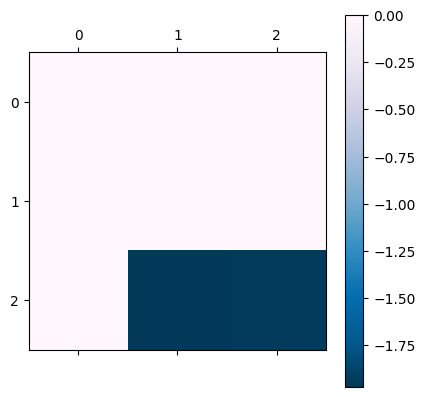

In [ ]:
plt.matshow((solver.v - primal_out2.x).reshape(size, size), cmap='PuBu_r') # plot the difference between the value function and the solution of the linear program
plt.colorbar()

**Answer:**

As expected we see that not all states coincide with V*. This is because all mu are 0 except for one state (the lower left). Interestingly some of the states do coincide with V*, but not the two bottom right. As mentioned previously, this is expected, since the LP doesn't care about the other states, but if it is needed to solve for the lower left state, then they will be solved.

# Ex 2: Solving the Dual [20 points]

Try now to solve the dual using again the `linprog` routine of scipy. 

Note that we did **not** overwrite `mu` (i.e. it is still uniform, and `primal_out.x` is the primal solution for this `mu`).

(*Hint:* Check slide 23 for the matrix form (or slide 11), lecture 3 to recall the dual.)

In [ ]:
# solve the dual LP with the correct inputs:
dual_out = linprog(-gridworld.r.flatten(), 
              A_eq= build_matrix(gridworld).T, 
              b_eq= -(1 - gridworld.gamma)*mu,
              method="simplex",
              bounds=(0, None))

/var/folders/7y/2z6fy9wj2gvdg90fmrn33q4h0000gn/T/ipykernel_15317/2923942678.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  dual_out = linprog(-gridworld.r.flatten(),


We verify that **strong duality** holds:

In [ ]:
dual_value = dual_out.x.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions)) # compute the optimal value of the dual
primal_value = (1 - gridworld.gamma)*primal_out.x.dot(mu)[0] # compute the optimal value of the primal
abs(primal_value - dual_value) # print the absolute difference between the primal and dual optimum

np.float64(8.326672684688674e-17)

Note that the solution of the dual problem gives us the **optimal occupancy measure**. Given this:

1. Obtain the **greedy policy** given the solution of the primal problem.

2. **Evaluate** this policy and **compare** the obtained values with the solution of the dual problem.

In [ ]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            action_taken = pi[s]
            v[s] = q[s,action_taken]
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

In [ ]:
pi = dual_out.x.reshape(gridworld.n_states,gridworld.n_actions).argmax(axis=1) # side remark/explanation: We know a deterministic optimal policy exists. It turns out that we can find it by checking for which component a lambda_opt(s,a) is > 0, and then setting pi_opt(a|s) = 1 for that action.
v,q = evaluate_policy(pi,gridworld) # evaluate the policy
print(np.linalg.norm(v-primal_out.x)) # print the 2-norm between the value function and the solution of the primal LP

4.111484296790486e-14


***Questions***

Derive the dual from the primal. That is, show that it indeed the dual linear program of the primal program (and that thus the values coincide by strong duality).

(*Hint:* You may consult the supplementary material of lecture 3, slide 9 and 10 in the appendix to read about strong duality in LPs. Make sure to explain step by step why it works.)

***Answer:***

TODO: ???

# Ex 3: Implement REPS with known dynamics [20 points]

In this exercize you will **implement the REPS algorithm** as we have seen in the lectures.
Namely, recall the following **details of the algorithm**:

1. **Initialization** (uniform): $\forall s, a, \lambda_0(s,a) = \frac{1}{|\mathcal{S}||\mathcal{A}|}$;

2. **REPS loss computation**: $\mathcal{L}(\lambda, V) = (1-\gamma) \langle \mu, V \rangle + \frac{1}{\eta}\log{\langle \lambda, \exp{(\eta(r+\gamma P V - E V))} \rangle}$;

3. **Solving for the values**: $V_{k}=\text{argmin}_{V}~{\mathcal{L}(\lambda_k, V)}$, for this we will use the `minimize` function from `scipy.optimize`;

4. **Updating the occupancy measure:** $\lambda_{k+1} \propto \lambda_k \cdot \exp{(\eta (r+\gamma P V_{k} - E V_{k}))}$ (unnormalized, you then must make sure it sums to 1 in every step).

In [ ]:
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax
from plot import plot_log_lines, plot_lines

In [ ]:
def reps_loss(lambda_, V, eta, initial): # return the reps loss
    # Bellman residual: delta(s,a) = r(s,a) + gamma*[PV](s,a) - [EV](s,a)
    # build_matrix returns (gamma*P - E), so delta = r + (gamma*P - E)*V
    delta = gridworld.r.reshape(gridworld.n_states * gridworld.n_actions) + build_matrix(gridworld).dot(V)
    # REPS loss: (1-gamma)*mu^T*V + (1/eta)*log(lambda^T * exp(eta*delta))
    # logsumexp: log(sum_i lam_i*exp(eta*d_i)) = logsumexp(eta*d + log(lam))
    loss = (1 - gridworld.gamma) * initial.flatten().dot(V) + (1 / eta) * logsumexp(eta * delta + np.log(lambda_))
    return loss

def minimize_reps_loss(lambda_, eta, initial): # find minimizer of the reps loss
    loss = lambda V : reps_loss(lambda_, V, eta, initial)
    V = minimize(loss, np.zeros(gridworld.n_states), method = "CG", options={'maxiter': 1000})
    return V.x

In [ ]:
K = 40 # number of iterations
mu = np.ones((gridworld.n_states,1))/gridworld.n_states # initialize mu again to the uniform distribution (not needed, just to be safe)

#initialize the variables
subopts = []
feasibility_errors = []
lambda_ = np.ones(gridworld.n_states*gridworld.n_actions)/gridworld.n_states/gridworld.n_actions
iterates = [lambda_]
subopts.append(-lambda_.T.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions))+(1-gridworld.gamma)*mu.T.dot(solver.v)[0])
feasibility_error = np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1-gridworld.gamma)*mu)
feasibility_errors.append(feasibility_error)

# REPS: iterate over K steps
for k in range(K):
    eta = 1/np.sqrt(k+1) # set the step size
    
    V = minimize_reps_loss(lambda_, eta, mu) # minimize the reps loss
    delta = gridworld.r.reshape(gridworld.n_states*gridworld.n_actions) + build_matrix(gridworld).dot(V) # compute the advantage function
    
    # lambda_{k+1} proportional to lambda_k * exp(eta * delta)
    new_lambda_ = lambda_ * np.exp(eta * delta) # update the lambda
    new_lambda_ /= np.sum(new_lambda_) # normalize the lambda_
    lambda_ = new_lambda_
    
    # store the suboptimality and feasibility errors:
    subopt = -lambda_.T.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions))+(1-gridworld.gamma)*mu.T.dot(solver.v)[0]
    feasibility_error = np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1-gridworld.gamma)*mu)
    subopts.append(subopt)
    feasibility_errors.append(feasibility_error)
    iterates.append(lambda_)

**Plot of the suboptimality of iterates produced by REPS**

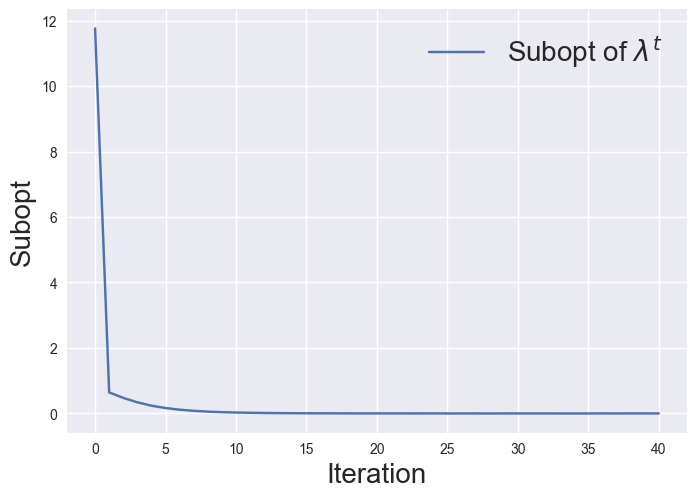

In [ ]:
plot_lines([np.array(subopts)], [r"Subopt of $\lambda^t$"], ["Iteration", "Subopt"], "figs", "subopts.pdf", show = True)

**Theoretical Derivation of REPS**

Prove that the iterates of REPS are equivalent to the iterates produced by the following updates:

$$ \lambda_{k+1} = \mathrm{argmax}_{\lambda} \left( \langle \lambda, r \rangle - \frac{1}{\eta} \left\langle \lambda,~ \log\left(\frac{\lambda}{\lambda_k}\right) \right\rangle \right) \quad \text{s.t.} \quad E^T \lambda = \gamma P^T \lambda + (1 - \gamma) \mu. $$

(*Hint:* Check the slides of lecture if you do not know where to start.)

**Answer:**

**Proof.** We add a Lagrange multiplier $V \in \mathbb{R}^{|\mathcal{S}|}$ for the constraint $E^\top\lambda - \gamma P^\top\lambda - (1-\gamma)\mu = 0$. This gives us the Lagrangian:

$$\mathcal{G}(\lambda, V) = \langle\lambda, r\rangle - \frac{1}{\eta}\left\langle\lambda, \log\frac{\lambda}{\lambda_k}\right\rangle + \left\langle V,\; \gamma P^\top\lambda + (1-\gamma)\mu - E^\top\lambda\right\rangle.$$

We can rewrite this using $(\gamma P - E)^\top = \gamma P^\top - E^\top$:

$$\mathcal{G}(\lambda, V) = \sum_{s,a}\lambda(s,a)\left[r(s,a) + [(\gamma P - E)V](s,a) - \frac{1}{\eta}\log\frac{\lambda(s,a)}{\lambda_k(s,a)}\right] + (1-\gamma)\langle\mu, V\rangle.$$

We take the derivative with respect to $\lambda(s,a)$ and set it to zero:

$$r(s,a) + [(\gamma P - E)V](s,a) - \frac{1}{\eta}\left(\log\frac{\lambda(s,a)}{\lambda_k(s,a)} + 1\right) = 0.$$

Rearranging to get $\lambda(s,a)$:

$$\lambda(s,a) = \lambda_k(s,a)\cdot\exp\left(\eta\left(r(s,a) + \gamma[PV](s,a) - [EV](s,a)\right) - 1\right).$$

The $e^{-1}$ part is the same for all $(s,a)$, so it disappears when we normalize $\lambda_{k+1} \leftarrow \lambda / \|\lambda\|_1$. This gives us:

$$\boxed{\lambda_{k+1} \propto \lambda_k \odot \exp\!\left(\eta(r + \gamma PV - EV)\right)}$$

which is exactly the REPS update rule.

Next, we plug this $\lambda^*$ back into $\mathcal{G}$ to find the best $V$. Using $\log(\lambda^*/\lambda_k) = \eta\,\delta - 1$ where $\delta = r + (\gamma P - E)V$, we get:

$$\boxed{\min_V\;\mathcal{G}(\lambda^*, V) = \min_V\;\mathcal{L}(\lambda_k, V)}$$

So finding the best $V$ is the same as minimizing the REPS loss.

**Plot the constraints violation**

Plot the value of $||(E^T - \gamma P^T)\lambda - (1 - \gamma) \mu || $, varying the parameter `maxiter` of the `scipy.minimize` function.

(To be clear: in the code above, modify this line ```minimize(loss, np.zeros(gridworld.n_states), method = "CG", options={'maxiter': 1000})``` and plot for varying `maxiter`.)

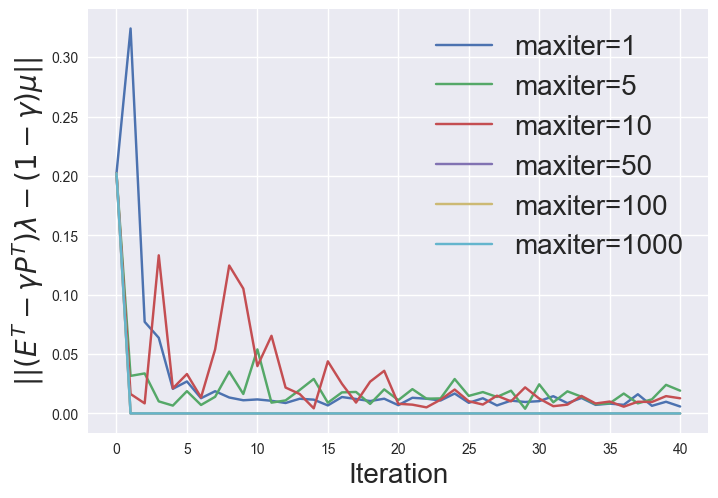

In [ ]:
# you may use this cell to experiment with the parameter and keep the one above the same if it helps you to keep the overview
# Experiment with different maxiter values
maxiter_values = [1, 5, 10, 50, 100, 1000]
all_feasibility_errors = []
labels = []

for maxiter_val in maxiter_values:
    # Redefine minimize_reps_loss
    def minimize_reps_loss_exp(lambda_, eta, initial, maxiter=maxiter_val):
        loss = lambda V: reps_loss(lambda_, V, eta, initial)
        V = minimize(loss, np.zeros(gridworld.n_states), method="CG", options={'maxiter': maxiter})
        return V.x

    # REPS with this maxiter
    lambda_exp = np.ones(gridworld.n_states * gridworld.n_actions) / gridworld.n_states / gridworld.n_actions
    feas_errors_exp = []
    feas_errors_exp.append(np.linalg.norm(build_matrix(gridworld).T.dot(lambda_exp) + (1 - gridworld.gamma) * mu))

    for k in range(K):
        eta = 1 / np.sqrt(k + 1)
        V = minimize_reps_loss_exp(lambda_exp, eta, mu)
        delta = gridworld.r.reshape(gridworld.n_states * gridworld.n_actions) + build_matrix(gridworld).dot(V)
        new_lambda_exp = lambda_exp * np.exp(eta * delta)
        new_lambda_exp /= np.sum(new_lambda_exp)
        lambda_exp = new_lambda_exp
        feas_errors_exp.append(np.linalg.norm(build_matrix(gridworld).T.dot(lambda_exp) + (1 - gridworld.gamma) * mu))

    all_feasibility_errors.append(np.array(feas_errors_exp))
    labels.append(f"maxiter={maxiter_val}")

plot_lines(all_feasibility_errors, labels, ["Iteration", "$|| (E^T - \\gamma P^T)\\lambda - (1 - \\gamma) \\mu ||$"], "figs", "constraints_vary_maxiter.pdf", show=True)

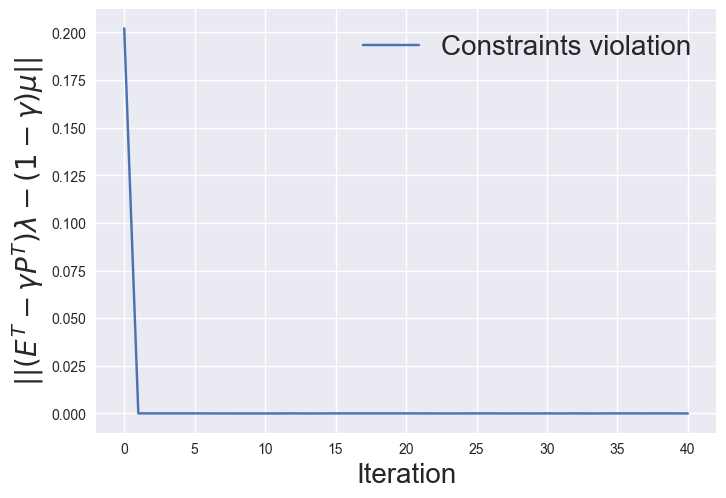

In [ ]:
plot_lines([np.array(feasibility_errors)], [r"Constraints violation"], ["Iteration", "$|| (E^T - \gamma P^T)\lambda - (1 - \gamma) \mu ||$"], "figs", "constraints.pdf", show = True)

**Question**

Empirically, is the value of $||(E^T - \gamma P^T)\lambda - (1 - \gamma) \mu || $ higher for high or low values of `maxiter`?

Explain why this is the case.

**Answer:**

$$\boxed{\text{The constraint violation is higher for low \texttt{maxiter} and lower for high \texttt{maxiter}.}}$$

The constraint $E^\top\lambda = \gamma P^\top\lambda + (1-\gamma)\mu$ is not enforced directly in the code. Instead, it is handled through the value $V_k$, which we get by minimizing the REPS loss. When `maxiter` is small, the solver stops too early and gives us a bad $V_k$. Since $V_k$ is what keeps the constraint in check, a bad $V_k$ means the constraint gets violated more. When `maxiter` is large, the solver has enough time to find a good $V_k$, so the constraint is satisfied more closely.

**Question:**

Strictly speaking, are the actual iterates $\lambda_k$ in the implementation above valid occupancy measures? In other words, is $E^T \lambda_k = \gamma P^T \lambda_k + (1 - \gamma) \mu$ strictly satisfied for all iterates? Explain why this is (not) the case.

**Answer:**

$$\boxed{\text{No, the iterates } \lambda_k \text{ are not valid occupancy measures in general.}}$$

A valid occupancy measure must satisfy $E^\top\lambda = \gamma P^\top\lambda + (1-\gamma)\mu$ exactly. In the REPS implementation, this constraint is enforced only *implicitly* via the Lagrange multiplier $V_k$ obtained from the inner minimization $\min_V \mathcal{L}(\lambda_k, V)$. Since this minimization is solved *approximately* (using CG with finite `maxiter`), the constraint is only approximately satisfied, not exactly. Furthermore, even with perfect inner optimization, the multiplicative update followed by normalization does not algebraically guarantee exact constraint satisfaction at each iterate, it only does so at convergence. The iterates $\lambda_k$ approach a valid occupancy measure as $k \to \infty$ and as `maxiter` increases.

**Plot of the suboptimality of the policies extracted from the $\lambda^k$'s**

*Extract the policies from the $\lambda^k$-iterates:* $$\pi_{\lambda^k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda_k(s,a)}.$$

In [ ]:
def extract_policies_from_occ_measures(occ_measures): # extract the policies from the occupancy measures
    policies = []
    for occ_measure in occ_measures:
        policy = np.zeros((gridworld.n_states, gridworld.n_actions)) # initialize the policy
        occ_measure = occ_measure.reshape(gridworld.n_states, -1) # reshape the occupancy measure
        states_occ_measure = occ_measure.sum(axis=1) # compute the occupancy measure over states (not state-action pairs)
        for s in range(gridworld.n_states):
            # pi(a|s) = lambda(s,a) / sum_a' lambda(s,a')
            policy[s] = occ_measure[s] / states_occ_measure[s] # compute the policy
        policies.append(policy)
        
    return policies

In [ ]:
policies = extract_policies_from_occ_measures(iterates)

*Extract the occupancy measures from the policies:* $$ \lambda_{\pi_{\lambda^k}}(s,a) = (1 - \gamma)\sum^{\infty}_{t=0} \gamma^t \mathbb{P}[s_t=s,a_t=a | s_0 \sim \mu, \pi_{\lambda^k}].$$

In [ ]:
def extract_occ_measures_from_policies(policies): # extract the occupancy measures from the policies (we do not require you to follow this)
    occ_measures = []
    for policy in policies:
        v = - (1 - gridworld.gamma)*(mu.repeat(gridworld.n_actions,axis=1)*policy).reshape(gridworld.n_states*gridworld.n_actions)
        matrix = np.eye(gridworld.n_states*gridworld.n_actions)
        T_pi = np.expand_dims(gridworld.T.transpose((1,0,2)),axis=3).repeat(gridworld.n_actions, axis=3)
        pi_tensor = np.expand_dims(policy, axis=(0,1)).repeat(T_pi.shape[0], axis=0).repeat(T_pi.shape[1], axis=1)
        T_pi = T_pi*pi_tensor
        matrix = gridworld.gamma*T_pi.reshape(gridworld.n_states*gridworld.n_actions,gridworld.n_states*gridworld.n_actions)- matrix
        occ_measure = np.linalg.solve(matrix.T, v)
        occ_measures.append(occ_measure)
    return occ_measures

In [ ]:
occ_measures = extract_occ_measures_from_policies(policies)

*Check whether $\lambda_{\pi_{\lambda_k}} = \lambda_k$*:

In [ ]:
# compute the difference between the occupancy measures and the iterates
diff_occ_measures = [np.linalg.norm(occ_measure - iterate) for occ_measure, iterate in zip(occ_measures, iterates)] 

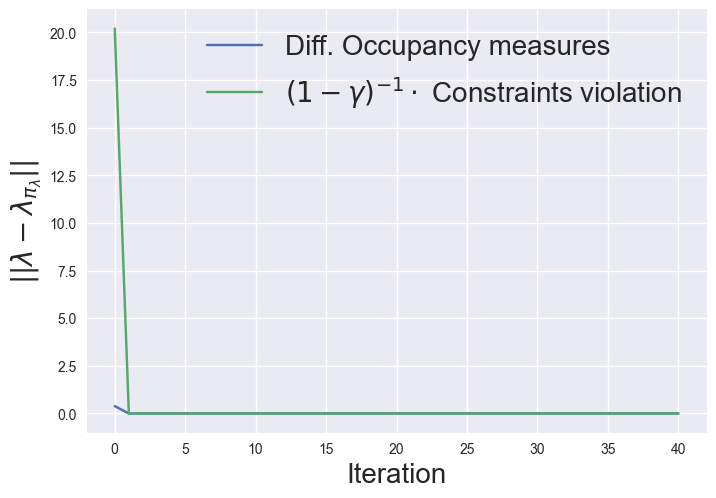

In [ ]:
# plot the difference between the occupancy measures and the iterates
plot_lines([np.array(diff_occ_measures), np.array(feasibility_errors)/(1 - gridworld.gamma)], [r"Diff. Occupancy measures", r"$(1-\gamma)^{-1}\cdot$ Constraints violation"], ["Iteration", "$|| \lambda - \lambda_{\pi_\lambda}||$"], "figs", "diff_occ_measures.pdf", show = True)

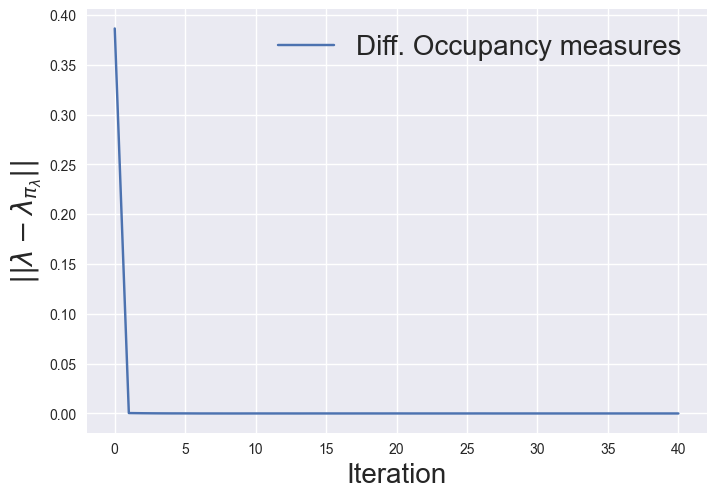

In [ ]:
plot_lines([np.array(diff_occ_measures)], [r"Diff. Occupancy measures"], ["Iteration", "$|| \lambda - \lambda_{\pi_\lambda}||$"], "figs", "diff_occ_measures_only.pdf", show = True)

**Questions**

- How does the norm of the difference $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ relate to the constraint violation $|| (E^T - \gamma P^T)\lambda^k - (1 - \gamma) \mu ||$ ?

- If $|| (E^T - \gamma P^T)\lambda^k - (1 - \gamma) \mu ||$ is small, can you conclude that $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ is also small ? 

*Hint: For both, you can answer leveraging the result in Lemma 3 of https://arxiv.org/pdf/2112.14004.pdf*

- As a consequence how is $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ affected by the value of `maxiter`?

*Hint:* Recall your empirical finding about the impact of `maxiter` (above).

***Answer:***

**Q1:** By Lemma 3 of *https://arxiv.org/pdf/2112.14004.pdf*, for any non-negative $\lambda$ with $\|\lambda\|_1 = 1$:

$$\boxed{\|\lambda - \lambda_{\pi_\lambda}\|_1 \leq \frac{1}{1-\gamma}\|(E^\top - \gamma P^\top)\lambda - (1-\gamma)\mu\|_1}$$

The gap between $\lambda^k$ and the true occupancy measure $\lambda_{\pi_{\lambda^k}}$ of the policy it defines is at most $\frac{1}{1-\gamma}$ times the constraint violation. The plot confirms this, the two curves follow each other closely.

**Q2:**

$$\boxed{\text{Yes, small constraint violation means small } \|\lambda^k - \lambda_{\pi_{\lambda^k}}\|.}$$

This follows directly from the bound above. If the right-hand side is small, the left-hand side must be small too.

**Q3:**

$$\boxed{\text{Higher \texttt{maxiter} reduces } \|\lambda^k - \lambda_{\pi_{\lambda^k}}\|.}$$

We already saw that higher `maxiter` leads to smaller constraint violation. And since constraint violation controls $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$, higher `maxiter` also makes this gap smaller. The other way around: low `maxiter` gives big constraint violation, which gives a big gap between $\lambda^k$ and $\lambda_{\pi_{\lambda^k}}$.

**Evaluate the extracted policies**

In this section, we compute the value functions of the extracted policies which is $V^{\pi_{\lambda^k}}$

In [ ]:
def evaluate_policy_sequence(policies, env, tol=1e-10):
    values = []
    for pi in policies:
        v = np.zeros(env.n_states) # initialize value function
        q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
        while True:
            v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
            for a in range(env.n_actions):
                q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v) #calculate Q-value
            for s in range(env.n_states):
                v[s] = pi[s].dot(q[s]) #calculate value function by $v(s) = max_a Q(s,a)$
            if np.linalg.norm(v - v_old) < tol: # convergence criterion
                break
        values.append(v)
    return values

In [ ]:
def check_correctness(policies):
    values = evaluate_policy_sequence(policies, gridworld) # evaluate the policies
    for policy,v in zip(policies,values):
        state_occ_measure = solver.mu_policy(policy, stochastic=True) # compute the state occupancy measure
        occ_measure = np.expand_dims(state_occ_measure, axis=1).repeat(gridworld.n_actions, axis=1)*policy
        primal = occ_measure.reshape(gridworld.n_states*gridworld.n_actions).dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions)) # compute the primal value
        dual = (1 - gridworld.gamma)*mu.T.dot(v) # compute the dual value
        assert primal - dual < 1e-7
    return [ (1 - gridworld.gamma)*mu.T.dot(v) for v in values] # return the values

**Question**

Do you expect $(1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle$ to be (approximately) equal to or (very) different from $\langle \lambda^k, r \rangle $? Does the answer depend on the value of `maxiter`?

*Hint: Recall that $(1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle = \langle \lambda_{\pi_{\lambda^k}}, r \rangle $ and argue using your previous answer concerning the term $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$.*

**Answer:**

By a standard identity, for any policy $\pi$: $(1-\gamma)\langle\mu, V^\pi\rangle = \langle\lambda_\pi, r\rangle$. So the difference between the two quantities is:

$$\left|(1-\gamma)\langle\mu, V^{\pi_{\lambda^k}}\rangle - \langle\lambda^k, r\rangle\right| = \left|\langle\lambda_{\pi_{\lambda^k}} - \lambda^k, r\rangle\right| \leq \|r\|_\infty \|\lambda_{\pi_{\lambda^k}} - \lambda^k\|_1.$$

From our previous answer, $\|\lambda_{\pi_{\lambda^k}} - \lambda^k\|_1$ depends on constraint violation, which depends on `maxiter`.

$$\boxed{\text{The two values are roughly equal for high \texttt{maxiter}, but can be very different for low \texttt{maxiter}.}}$$

- High `maxiter`: Constraint violation is small, so $\lambda^k \approx \lambda_{\pi_{\lambda^k}}$, and the two values are close.
- Low `maxiter`: Constraint violation is big, so $\lambda^k$ and $\lambda_{\pi_{\lambda^k}}$ can be far apart, and the two values can be very different.

So yes, the answer depends on `maxiter`.

In [ ]:
policy_values = check_correctness(policies) # check that $(1 - \gamma)\langle \mu, V^{\pi} \rangle = \langle \lambda_{\pi}, r \rangle $ for all policies.
policy_subopts = (1 - gridworld.gamma)*mu.T.dot(solver.v) - policy_values # compute the suboptimality of the policies

**Plot the suboptimalities**

Plot $(1 - \gamma)\langle \mu, V^{\pi^\star}\rangle - (1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle$.

Plot $(1 - \gamma)\langle \mu, V^{\pi^\star}\rangle - \langle \lambda^k, r \rangle$.

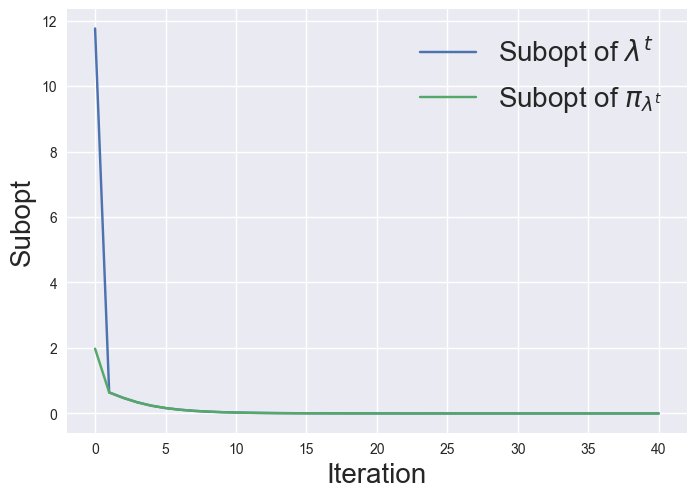

In [ ]:
plot_lines([np.array(subopts), policy_subopts.flatten()], [r"Subopt of $\lambda^t$", r"Subopt of $\pi_{\lambda^t}$"], ["Iteration", "Subopt"], "figs", "subopts.pdf", show = True)

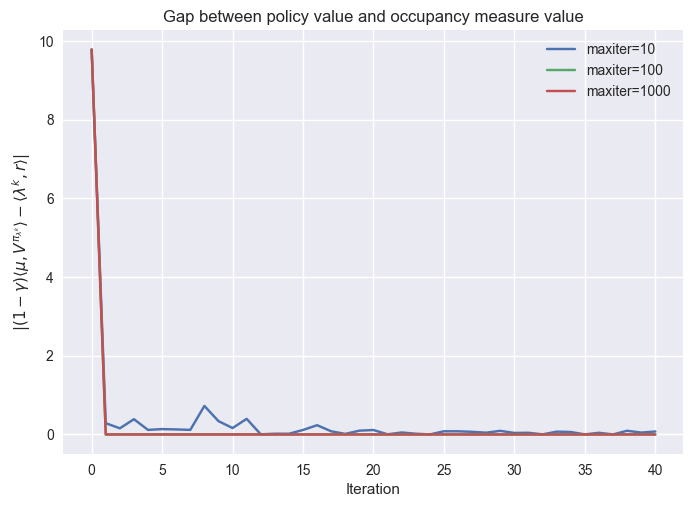

In [ ]:
# Experiment loop to also compare (1-gamma)<mu, V^{pi}> vs <lambda, r>
maxiter_test_values = [10, 100, 1000]
r_flat = gridworld.r.reshape(gridworld.n_states * gridworld.n_actions)

for maxiter_val in maxiter_test_values:
    def minimize_reps_loss_exp(lambda_, eta, initial, maxiter=maxiter_val):
        loss = lambda V: reps_loss(lambda_, V, eta, initial)
        V = minimize(loss, np.zeros(gridworld.n_states), method="CG", options={'maxiter': maxiter})
        return V.x

    lambda_exp = np.ones(gridworld.n_states * gridworld.n_actions) / gridworld.n_states / gridworld.n_actions
    iterates_exp = [lambda_exp]

    for k in range(K):
        eta = 1 / np.sqrt(k + 1)
        V = minimize_reps_loss_exp(lambda_exp, eta, mu)
        delta = r_flat + build_matrix(gridworld).dot(V)
        new_lambda_exp = lambda_exp * np.exp(eta * delta)
        new_lambda_exp /= np.sum(new_lambda_exp)
        lambda_exp = new_lambda_exp
        iterates_exp.append(lambda_exp)

    # Extract policies and get their true values
    policies_exp = extract_policies_from_occ_measures(iterates_exp)
    policy_values_exp = check_correctness(policies_exp)

    # Compute <lambda^k, r> and compare
    diffs = [abs(pv - lam.dot(r_flat)) for pv, lam in zip(policy_values_exp, iterates_exp)]

    plt.plot(diffs, label=f"maxiter={maxiter_val}")

plt.xlabel("Iteration")
plt.ylabel(r"$|(1-\gamma)\langle\mu, V^{\pi_{\lambda^k}}\rangle - \langle\lambda^k, r\rangle|$")
plt.title("Gap between policy value and occupancy measure value")
plt.legend()
plt.show()

## Ex 4: Lagrangian methods [ 20 points ]

In this section we compute an optimal policy finding a saddle point of the Lagrangian $\mathcal{L}(\lambda, V)$, defined as follows

$$
\mathcal{L}(\lambda, V) = \langle \lambda, r \rangle + \langle (1 - \gamma) \mu + \gamma P^T \lambda - E^T \lambda, V \rangle .
$$

Finding a saddle point of the Lagrangian means solving the following problem:

$$ 
\mathrm{argmax}_{\lambda \geq 0} \min_{V \in \mathbb{R}^{|\mathcal{S}|}} \mathcal{L}(\lambda, V).
$$

By slide 6 in Lecture 3 it should be clear that there exists a saddle point pair $\lambda^\star, V^\star$ such that $|| V^\star ||_{\infty} \leq \frac{\max_{s,a} |r(s,a)|}{1 - \gamma}$. Therefore, we can consider looking for a saddle point over a restricted domain $\mathcal{V} = \{ V : ||V||_{\infty} \leq \frac{\max_{s,a} |r(s,a)|}{1 - \gamma} \}$:

$$ 
\mathrm{argmax}_{\lambda \geq 0} \min_{V \in \mathcal{V}} \mathcal{L}(\lambda, V).
$$

At this point we solve this problem with gradient descent ascent updates 

$$
\lambda^{k+1} \propto \lambda^k \odot \exp(\eta_{\lambda} \nabla_{\lambda} \mathcal{L}(\lambda^k, V^k)),
$$

$$
V^{k+1} = \Pi_{\mathcal{V}}[V^k - \eta_V \nabla_{V} \mathcal{L}(\lambda^k, V^k)].
$$

**Question**: 

Compute the following gradients:

$$  \nabla_{\lambda} \mathcal{L}(\lambda^k, V^k) = ??? $$

$$ \nabla_{V} \mathcal{L}(\lambda^k, V^k) = ??? $$

**Question:**

Which of the following conditions ensure that the policy $$\pi_{\lambda^k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda^k(s,a)}$$ is $\epsilon$-suboptimal ?

(a) $$\langle \lambda^\star, r \rangle - \langle \lambda^k, r \rangle \leq \epsilon.$$
(b) $$(1 - \gamma)\langle \mu, V^\star \rangle - \langle \mu, V^k \rangle \leq \epsilon.$$
(c) $$ \mathcal{L}(\lambda^\star, V^k) - \mathcal{L}(\lambda^k, V^{\pi^{\lambda^k}}) \leq \epsilon.$$

Answer (a),(b) or (c).

**Answer**

### * Question [20 points]

Prove that the answer you gave at the question above implies that the policy $$\pi_{\lambda_k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda^k(s,a)}$$ is $\epsilon$-suboptimal.
*Recall:* A policy $\pi$ is $\epsilon$-suboptimal if $ (1 - \gamma)  \langle\mu , V^\star - V^{\pi} \rangle\leq \epsilon$

 **Answer**